## EDA

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns

In [24]:
df = pd.read_csv("data/ta_restaurants.csv")
df.head()

,rating,reviews_count,cuisine_type,price,is_sponsored
0,"5,0",3,"Средиземноморская, Греческая",$$ - $$$,True
1,"4,1",97,"Бары и клубы, Стейк-хаус",$$ - $$$,True
2,"4,8",3316,"Французская, Стейк-хаус",$$$$,False
3,"4,3",518,"Китайская, Японская",$,False
4,"4,7",3995,"Итальянская, Пицца",$$ - $$$,False


In [25]:
df.shape

(10499, 5)

In [26]:
df['rating'] = df['rating'].str.replace(',', '.').astype('float')

In [27]:
df.isna().sum()

rating           1818
reviews_count       0
cuisine_type      293
price            4234
is_sponsored        0
dtype: int64

In [28]:
len(df[df['reviews_count'] == 0])

1812

In [29]:
df[(df['reviews_count'] != 0) & (df['rating'].isna())]

,rating,reviews_count,cuisine_type,price,is_sponsored
2740,NaN,1,"Итальянская, Современная",NaN,False
7291,NaN,1,Американская,NaN,False
7445,NaN,1,Американская,NaN,False
7729,NaN,1,"Азиатская, Тайская",NaN,False
7763,NaN,1,Пицца,NaN,False
7810,NaN,1,Японская,NaN,False


В основном, rating отсутствует тогда, когда попросту нет отзывов (1812 случаев из 1818). У остальных 6 всего по 1 отзыву.

In [30]:
df = df.dropna(subset=['rating', 'price', 'cuisine_type'])

In [31]:
price_levels = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4, '$$$$$': 5}

df['lowest_price'] = df['price'].str.replace(' ', '').str.split('-').str[0].map(price_levels)
df['max_price'] = df['price'].str.replace(' ', '').str.split('-').str[-1].map(price_levels)

In [32]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,lowest_price,max_price
0,5.0,3,"Средиземноморская, Греческая",$$ - $$$,True,2,3
1,4.1,97,"Бары и клубы, Стейк-хаус",$$ - $$$,True,2,3
2,4.8,3316,"Французская, Стейк-хаус",$$$$,False,4,4
3,4.3,518,"Китайская, Японская",$,False,1,1
4,4.7,3995,"Итальянская, Пицца",$$ - $$$,False,2,3
...,...,...,...,...,...,...,...
10463,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10464,4.5,130,"Бары и клубы, Ирландская",$,True,1,1
10465,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10482,4.5,27,"Японская, Азиатская",$$ - $$$,True,2,3


In [33]:
df = df[~df['cuisine_type'].fillna('').str.contains(
    r'Откроется|Закроется|Открыто|Сейчас|Сегодня|Меню', regex=True)]

In [34]:
df['cuisine_type'] = df['cuisine_type'].str.split(', ')

In [35]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,lowest_price,max_price
0,5.0,3,"[Средиземноморская, Греческая]",$$ - $$$,True,2,3
1,4.1,97,"[Бары и клубы, Стейк-хаус]",$$ - $$$,True,2,3
2,4.8,3316,"[Французская, Стейк-хаус]",$$$$,False,4,4
3,4.3,518,"[Китайская, Японская]",$,False,1,1
4,4.7,3995,"[Итальянская, Пицца]",$$ - $$$,False,2,3
...,...,...,...,...,...,...,...
10463,4.6,56,"[Итальянская, Пицца]",$$ - $$$,True,2,3
10464,4.5,130,"[Бары и клубы, Ирландская]",$,True,1,1
10465,4.6,56,"[Итальянская, Пицца]",$$ - $$$,True,2,3
10482,4.5,27,"[Японская, Азиатская]",$$ - $$$,True,2,3


In [36]:
df = df.explode('cuisine_type')

In [37]:
avg_rating_by_cuisine = df.groupby('cuisine_type')['rating'].agg(['mean', 'count', 'std'])

In [38]:
rare_cuisines = avg_rating_by_cuisine[avg_rating_by_cuisine['count'] < 9].index
rare_cuisines

Index(['Австралийская', 'Австрийская', 'Аргентинская', 'Армянская',
       'Афганская', 'Бангладешская', 'Бары с рестораном', 'Баскская',
       'Бельгийская', 'Британская', 'Венесуэльская', 'Восточноевропейская',
       'Гавайская', 'Гастропаб', 'Гриль', 'Грузинская', 'Кайсэки', 'Канадская',
       'Кантонская', 'Кубинская', 'Малазийская', 'Нонья', 'Паб с пивоварней',
       'Пакистанская', 'Персидская', 'Польская', 'Португальская', 'Римская',
       'Русская', 'Северно-итальянская', 'Сицилийская', 'Сычуаньская',
       'Тайваньская', 'Тибетская', 'Тосканская', 'Украинская', 'Уличная еда',
       'Хорватская', 'Центральноазиатская', 'Центральноамериканская',
       'Чешская', 'Шанхайская', 'Шведская', 'Швейцарская', 'Шриланкийская',
       'Эфиопская', 'Юнаньская', 'Ямайская', 'Японская кухня-фьюжн'],
      dtype='str', name='cuisine_type')

In [39]:
avg_rating_by_cuisine = avg_rating_by_cuisine.drop(index=rare_cuisines)

In [49]:
avg_rating_by_cuisine.sort_values('mean', ascending=False).head(10)

,mean,count,std
cuisine_type,,,
Греческая,4.895886,316,0.300078
Средиземноморская,4.675574,479,0.464434
Южноамериканская,4.455556,9,0.324465
Суши,4.442606,284,0.510783
Японская,4.400885,565,0.439393
Ирландская,4.380878,319,0.290810
Ливанская,4.357692,26,0.480144
Пицца,4.351178,594,0.412503
Африканская,4.344000,25,0.432127


In [50]:
avg_rating_by_cuisine.sort_values('count', ascending=False).head(10)

,mean,count,std
cuisine_type,,,
Американская,4.136392,1591,0.458452
Итальянская,4.292213,1053,0.421202
Азиатская,4.236874,659,0.398008
Бар,4.128550,655,0.461509
Пицца,4.351178,594,0.412503
Японская,4.400885,565,0.439393
Средиземноморская,4.675574,479,0.464434
Бары и клубы,4.307940,466,0.285945
Ирландская,4.380878,319,0.290810


<Axes: xlabel='rating', ylabel='Count'>

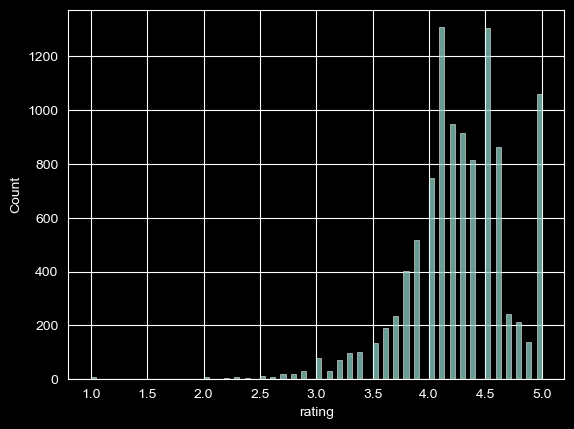

In [42]:
sns.histplot(data=df, x='rating')

In [43]:
pivot_rating = df.groupby(['lowest_price', 'max_price'])['rating'].mean().reset_index()

In [44]:
corr_df = pivot_rating.corr()
corr_df

,lowest_price,max_price,rating
lowest_price,1.000000,0.928571,0.785939
max_price,0.928571,1.000000,0.959286
rating,0.785939,0.959286,1.000000


<Axes: >

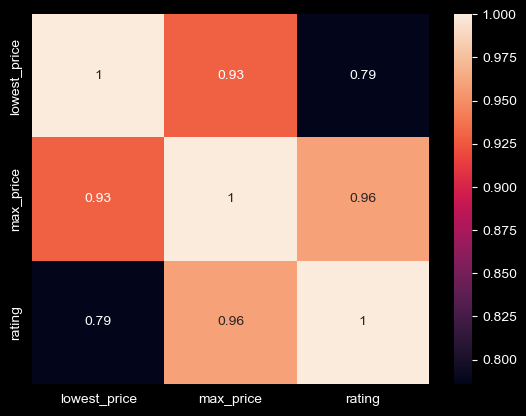

In [45]:
sns.heatmap(corr_df, annot=True)